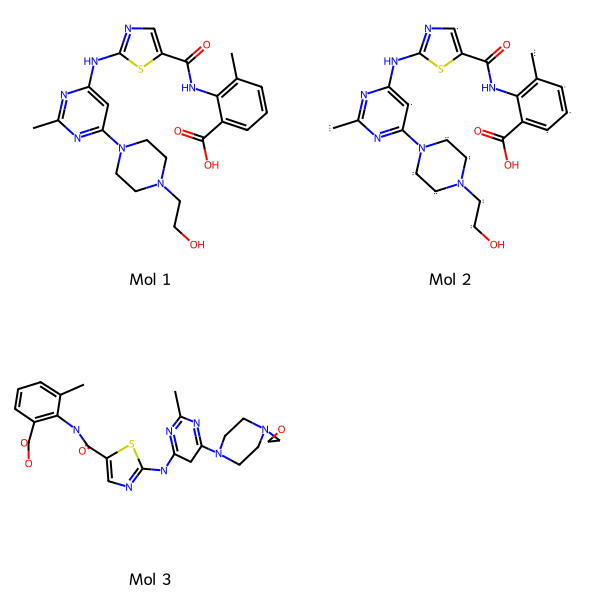

In [40]:
from rdkit import Chem
from rdkit.Chem import Draw

smiles = [
    "Cc1nc(Nc2ncc(C(=O)Nc3c(C)cccc3C(=O)O)s2)cc(N2CCN(CCO)CC2)n1",
    "[C]c1nc(Nc2n[c]c(C(=O)Nc3c([C])[c][c][c]c3C(=O)O)s2)[c]c(N2[C][C]N([C][C]O)[C][C]2)n1"
]

mols = [Chem.MolFromSmiles(smi) for smi in smiles]
sdf_file = "../tmp/mol_2026_01_23_08_14_28_238_docked.sdf"
loader = Chem.SDMolSupplier(sdf_file, sanitize=False)
for mol in loader:
    if mol is not None:
        mols.append(mol)
img = Draw.MolsToGridImage(mols, molsPerRow=2, subImgSize=(300, 300), legends=[f"Mol {i+1}" for i in range(len(mols))])
img.show()

In [ ]:
from openbabel import pybel
from openbabel import openbabel as ob

pdbqt_file = "../tmp/mol_2026_01_23_08_14_28_238_docked.pdbqt"
sdf_file = pdbqt_file.replace(".pdbqt", ".sdf")
mol = next(pybel.readfile("pdbqt", pdbqt_file))
mol.OBMol.BeginModify()
for atom in ob.OBMolAtomIter(mol.OBMol):
    if atom.GetAtomicNum() == 7 and atom.IsInRing() and atom.GetExplicitValence() > 3:
        for nbr in ob.OBAtomAtomIter(atom):
            if nbr.GetAtomicNum() == 6:
                print(nbr.GetIdx(), nbr.GetExplicitValence())
        for bond in ob.OBAtomBondIter(atom):
            # Reset all bonds to this nitrogen to Single
            nbr = bond.GetBeginAtom() if bond.GetEndAtom() == atom else bond.GetEndAtom()
            flag = False
            for nbr_nbr in ob.OBAtomAtomIter(nbr):
                if nbr_nbr.GetAtomicNum() == 7:
                    flag = True
                    break
            if not flag:
                print(bond.GetIdx(), bond.GetBondOrder())
                bond.SetAromatic(False)
                bond.SetBondOrder(1)

mol.OBMol.SetAromaticPerceived(True)
mol.OBMol.EndModify()
mol.OBMol.PerceiveBondOrders()

mol.write("sdf", sdf_file, overwrite=True)

4 4
2 4
